In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

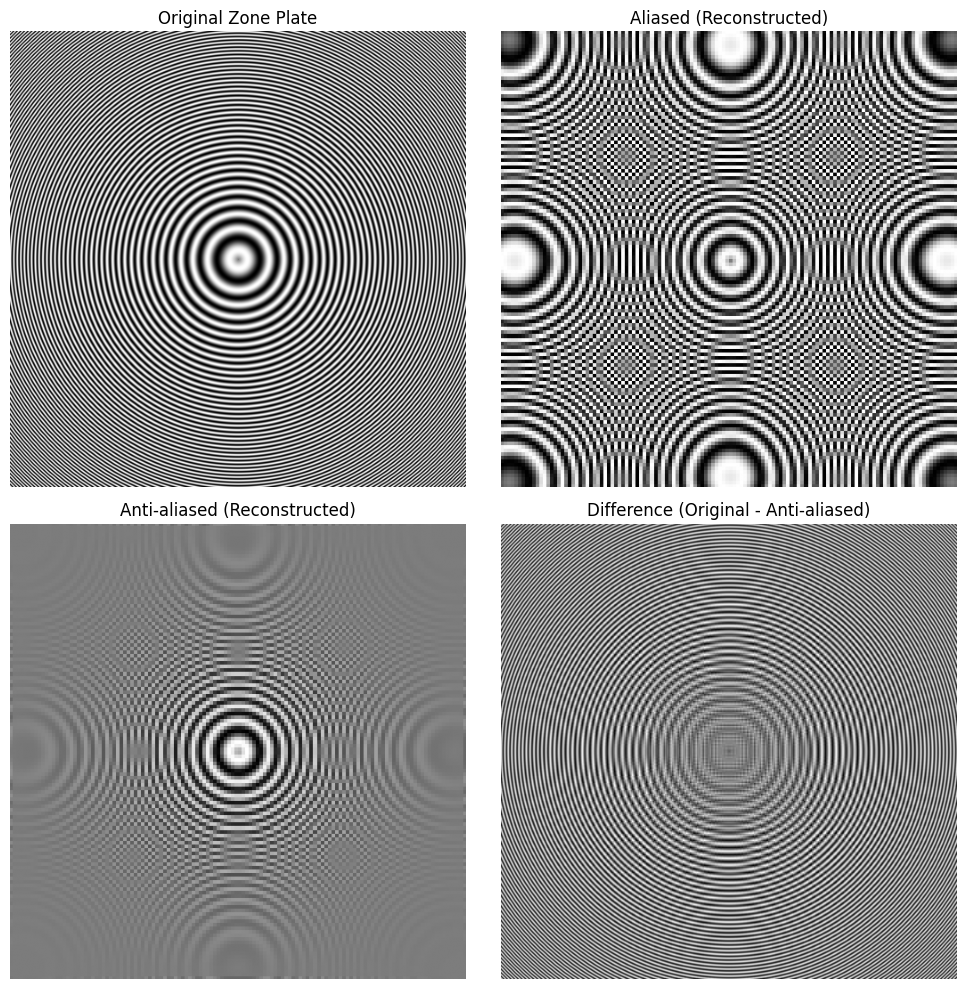

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import decimate, convolve2d, get_window
from skimage.transform import rescale
from scipy.ndimage import zoom

# 1. Generate a zone plate image
def generate_zone_plate(size):
    x = np.arange(size) / size - 0.5
    y = np.arange(size) / size - 0.5
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)
    # The frequency increases with radius
    f0 = 10
    k = 250
    # High frequency in center, lower towards edges
    zone_plate= np.sin(np.pi * 2 * (f0 * R + k * R**2 / 2))
    return zone_plate


image_size = 512
downsample_factor = 4
zp_original = generate_zone_plate(image_size)

# 2. Downsample without anti-aliasing filter (aliasing occurs)
# We can simulate this by direct slicing (nearest neighbor sampling)
zp_aliased = zp_original[::downsample_factor, ::downsample_factor]

# 3. Downsample with an anti-aliasing filter
# Scikit-image's rescale with anti_aliasing=True uses a Gaussian filter
zp_antialiased = rescale(zp_original, 1.0/downsample_factor, anti_aliasing=True, mode='reflect')

# 4. Reconstruct using zero-order hold (nearest neighbor interpolation)
# This involves upsampling the downsampled images back to the original size
# The zero-order hold is equivalent to nearest-neighbor interpolation when upsampling

# For the aliased image
zp_aliased_reconstructed = zoom(zp_aliased, downsample_factor, order=0) # order=0 is nearest neighbor

# For the anti-aliased image
zp_antialiased_reconstructed = zoom(zp_antialiased, downsample_factor, order=0) # order=0 is nearest neighbor

# Ensure the reconstructed images are the same size as the original
zp_aliased_reconstructed = zp_aliased_reconstructed[:image_size, :image_size]
zp_antialiased_reconstructed = zp_antialiased_reconstructed[:image_size, :image_size]

# 5. Display the results
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
ax = axes.ravel()

ax[0].imshow(zp_original, cmap='gray')
ax[0].set_title('Original Zone Plate')
ax[0].axis('off')

ax[1].imshow(zp_aliased_reconstructed, cmap='gray')
ax[1].set_title('Aliased (Reconstructed)')
ax[1].axis('off')

ax[2].imshow(zp_antialiased_reconstructed, cmap='gray')
ax[2].set_title('Anti-aliased (Reconstructed)')
ax[2].axis('off')

ax[3].imshow(zp_original - zp_antialiased_reconstructed, cmap='gray')
ax[3].set_title('Difference (Original - Anti-aliased)')
ax[3].axis('off')


plt.tight_layout() # Adjust layout to prevent titles overlapping
plt.show()